
Shape of dataset: (18442, 13)

Columns:
 Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Positive Feedback Count',
       'Division Name', 'Department Name', 'Class Name', 'Recommended IND',
       'doc_length', 'noun_count', 'verb_count', 'stopword_count'],
      dtype='object')

Missing values:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
doc_length                 0
noun_count                 0
verb_count                 0
stopword_count             0
dtype: int64

Target distribution:
Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64


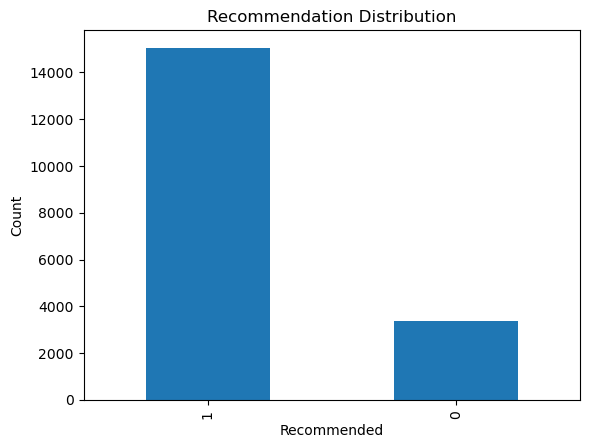


Model Evaluation:

              precision    recall  f1-score   support

           0       0.77      0.52      0.62       692
           1       0.90      0.96      0.93      2997

    accuracy                           0.88      3689
   macro avg       0.83      0.74      0.77      3689
weighted avg       0.87      0.88      0.87      3689


Best Parameters: {'model__C': 10, 'model__solver': 'lbfgs'}

Final Model Performance:

Model Evaluation:

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       692
           1       0.91      0.94      0.93      2997

    accuracy                           0.88      3689
   macro avg       0.82      0.78      0.80      3689
weighted avg       0.88      0.88      0.88      3689



In [50]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

import spacy

# Load spaCy model once (this is relatively heavy)
nlp = spacy.load("en_core_web_sm")


# ===============================
# DATA LOADING
# ===============================

def load_data(filepath):
    """
    Loads dataset from the given path.
    """
    df = pd.read_csv(filepath)
    return df


# ===============================
# DATA EXPLORATION
# ===============================

def explore_data(df):
    """
    Basic exploration to understand structure and quality.
    """
    print("\nShape of dataset:", df.shape)
    print("\nColumns:\n", df.columns)

    print("\nMissing values:\n", df.isnull().sum())

    print("\nTarget distribution:")
    print(df["Recommended IND"].value_counts(normalize=True))

    # Simple visualization
    df["Recommended IND"].value_counts().plot(kind="bar")
    plt.title("Recommendation Distribution")
    plt.xlabel("Recommended")
    plt.ylabel("Count")
    plt.show()


# ===============================
# SPACY FEATURE ENGINEERING
# ===============================

def add_spacy_features(df, text_col):
    """
    Adds spaCy-based features directly to dataframe.
    """

    texts = df[text_col].fillna("").astype(str).tolist()

    features = []

    for doc in nlp.pipe(texts, disable=["parser", "ner"]):
        features.append([
            len(doc),
            sum(1 for token in doc if token.pos_ == "NOUN"),
            sum(1 for token in doc if token.pos_ == "VERB"),
            sum(1 for token in doc if token.is_stop)
        ])

    feature_array = np.array(features)

    df["doc_length"] = feature_array[:, 0]
    df["noun_count"] = feature_array[:, 1]
    df["verb_count"] = feature_array[:, 2]
    df["stopword_count"] = feature_array[:, 3]

    return df

# ===============================
# PIPELINE BUILDING
# ===============================

def build_pipeline(text_col, num_cols, cat_cols):
    """
    Builds a full preprocessing + model pipeline.
    """

    # Text processing
    text_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english"))
    ])

    # Numerical processing
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # Categorical processing
    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Combine everything
    preprocessor = ColumnTransformer([
        ("text", text_pipeline, text_col),
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),

    ])

    # Full pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=3000))
    ])

    return pipeline


# ===============================
# TRAINING FUNCTION
# ===============================

def train_model(pipeline, X_train, y_train):
    """
    Trains the pipeline.
    """
    pipeline.fit(X_train, y_train)
    return pipeline


# ===============================
# EVALUATION FUNCTION
# ===============================

def evaluate_model(model, X_test, y_test):
    """
    Prints evaluation metrics.
    """
    y_pred = model.predict(X_test)
    print("\nModel Evaluation:\n")
    print(classification_report(y_test, y_pred))


# ===============================
# HYPERPARAMETER TUNING
# ===============================

def tune_model(pipeline, X_train, y_train):
    """
    Performs GridSearch to fine-tune model.
    """

    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"]
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        error_score="raise"
    )

    grid_search.fit(X_train, y_train)

    print("\nBest Parameters:", grid_search.best_params_)

    return grid_search.best_estimator_


# ===============================
# MAIN EXECUTION FLOW
# ===============================



# Load data
df = load_data("starter/data/reviews.csv")
df = add_spacy_features(df, "Review Text")

# Quick exploration
explore_data(df)
    

# Define columns
text_col = "Review Text"
num_cols = [
    "Age",
    "doc_length",
    "noun_count",
    "verb_count",
    "stopword_count"
]
cat_cols = ["Department Name", "Class Name"]
target = "Recommended IND"

# Drop rows with missing target or text
df = df.dropna(subset=[text_col, target])

# Features and target
X = df.drop(target, axis=1)
y = df[target]

    # Train-test split
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
)

# Build pipeline
pipeline = build_pipeline(text_col, num_cols, cat_cols)
# Step 3: Test pipeline first (debug step)
pipeline.fit(X_train, y_train)

# Train
model = train_model(pipeline, X_train, y_train)

# Evaluate
evaluate_model(model, X_test, y_test)

# Fine-tune
best_model = tune_model(pipeline, X_train, y_train)

# Final evaluation
print("\nFinal Model Performance:")
evaluate_model(best_model, X_test, y_test)




In [54]:
import joblib

#save the model
best_model = tune_model(pipeline, X_train, y_train)

#load the model for testing
joblib.dump(best_model, "model.pkl")

#test prediction
loaded_model = joblib.load("model.pkl")
sample_pred = loaded_model.predict(X_test[:5])
print(sample_pred)



Best Parameters: {'model__C': 10, 'model__solver': 'lbfgs'}
[1 1 1 1 0]


In [55]:
import streamlit as st
import joblib
import pandas as pd

# Load trained pipeline
model = joblib.load("model.pkl")


# -----------------------------
# UI
# -----------------------------

st.title("Fashion Recommendation Predictor")

st.write("Enter review details to predict whether a customer would recommend the product.")

# User inputs
review_text = st.text_area("Review Text")

age = st.slider("Age", 18, 80, 30)

department = st.selectbox(
    "Department Name",
    ["Tops", "Dresses", "Bottoms", "Intimate", "Jackets"]
)

product_class = st.text_input("Class Name", "General")


# -----------------------------
# Prediction
# -----------------------------

if st.button("Predict"):

    # Create input dataframe
    input_data = pd.DataFrame({
        "Review Text": [review_text],
        "Age": [age],
        "Department Name": [department],
        "Class Name": [product_class],
        "doc_length": [len(review_text)],
        "noun_count": [0],
        "verb_count": [0],
        "stopword_count": [0]
    })

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        st.success(f"Recommended ✅ (Confidence: {probability:.2f})")
    else:
        st.error(f"Not Recommended ❌ (Confidence: {probability:.2f})")

2026-03-29 00:10:45.574 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.623 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-29 00:10:45.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 00:10:45.627 Thread 'MainThread': m